# Pipeline de Entrenamiento: Prediccion de Tarifas de Uber

En este notebook implementamos el pipeline completo de entrenamiento para predecir tarifas de Uber, incluyendo:

1. Carga y limpieza de datos
2. Ingenieria de features
3. Entrenamiento con MLflow tracking
4. Evaluacion del modelo
5. Comparacion Champion vs Challenger

## Dataset

Usamos el [Uber Fares Dataset](https://www.kaggle.com/datasets/yasserh/uber-fares-dataset) de Kaggle.

**Variables:**
- `fare_amount`: Tarifa del viaje en USD (variable objetivo)
- `pickup_datetime`: Fecha y hora de inicio del viaje
- `passenger_count`: Numero de pasajeros
- `pickup_longitude/latitude`: Coordenadas de recogida
- `dropoff_longitude/latitude`: Coordenadas de destino

In [1]:
# Importaciones
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Carga de datos

Primero descarga el dataset de Kaggle y colocalo en `data/uber.csv`.

Link: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [2]:
# Cargar datos crudos
df_raw = pd.read_csv("../data/uber.csv")
print(f"Dimensiones: {df_raw.shape}")
df_raw.head()

Dimensiones: (200000, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
# Informacion general
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [4]:
# Estadisticas descriptivas
df_raw.describe().round(2)

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,200000.00,200000.00,200000.00,200000.00,199999.00,199999.00,200000.00
mean,27712503.68,11.36,-72.53,39.94,-72.53,39.92,1.68
std,16013822.21,9.90,11.44,7.72,13.12,6.79,1.39
min,1.00,-52.00,-1340.65,-74.02,-3356.67,-881.99,0.00
25%,13825346.25,6.00,-73.99,40.73,-73.99,40.73,1.00
50%,27745495.00,8.50,-73.98,40.75,-73.98,40.75,1.00
75%,41555300.75,12.50,-73.97,40.77,-73.96,40.77,2.00
max,55423567.00,499.00,57.42,1644.42,1153.57,872.70,208.00


In [5]:
# Valores nulos
print("Valores nulos por columna:")
print(df_raw.isnull().sum())

Valores nulos por columna:
Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


## 2. Analisis exploratorio rapido

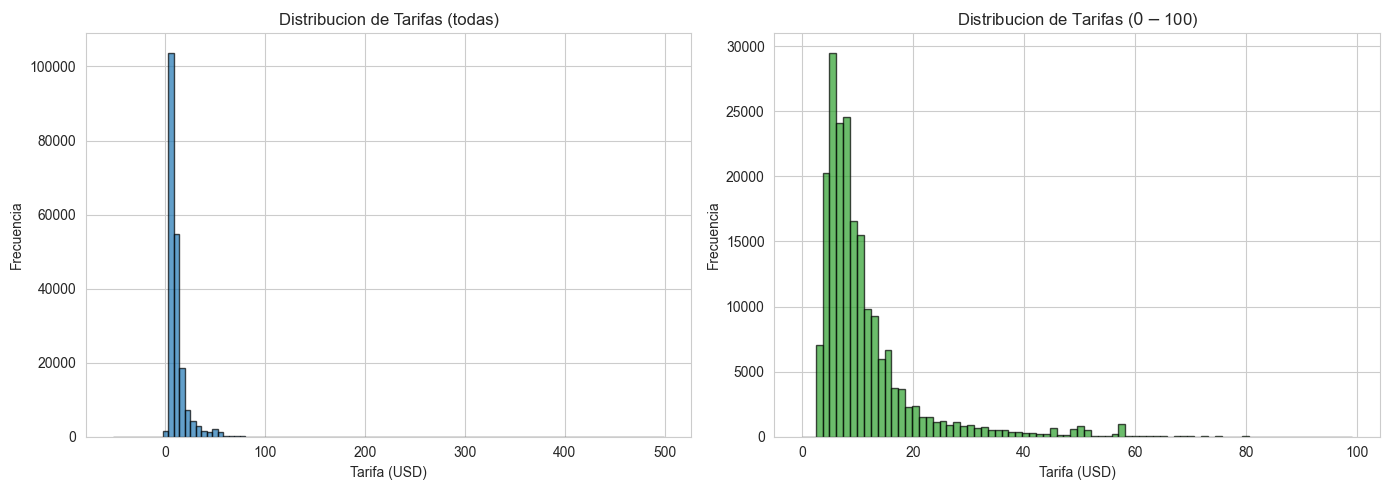

Tarifa promedio: $11.36
Tarifa mediana: $8.50


In [6]:
# Distribucion de la tarifa (variable objetivo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Todas las tarifas
axes[0].hist(df_raw["fare_amount"], bins=100, color="#1f77b4", edgecolor="k", alpha=0.7)
axes[0].set_title("Distribucion de Tarifas (todas)")
axes[0].set_xlabel("Tarifa (USD)")
axes[0].set_ylabel("Frecuencia")

# Filtrando outliers para mejor visualizacion
tarifas_razonables = df_raw[(df_raw["fare_amount"] > 0) & (df_raw["fare_amount"] < 100)]["fare_amount"]
axes[1].hist(tarifas_razonables, bins=80, color="#2ca02c", edgecolor="k", alpha=0.7)
axes[1].set_title("Distribucion de Tarifas ($0 - $100)")
axes[1].set_xlabel("Tarifa (USD)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(f"Tarifa promedio: ${df_raw['fare_amount'].mean():.2f}")
print(f"Tarifa mediana: ${df_raw['fare_amount'].median():.2f}")

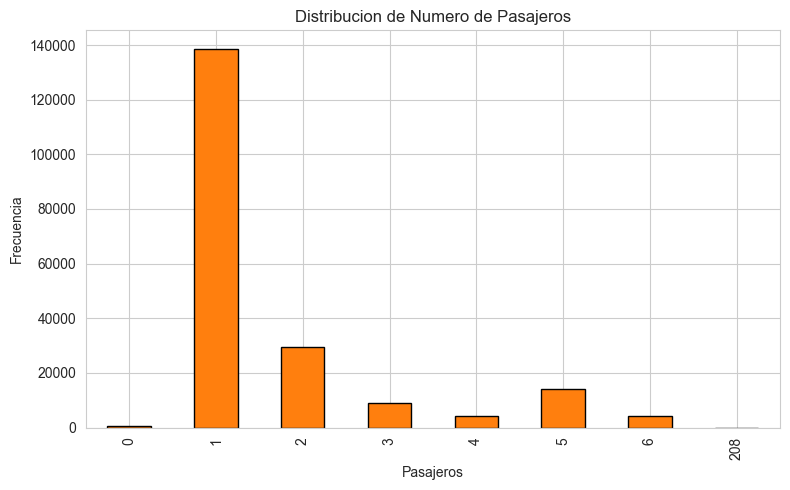

In [7]:
# Distribucion de pasajeros
fig, ax = plt.subplots(figsize=(8, 5))
df_raw["passenger_count"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#ff7f0e", edgecolor="k")
ax.set_title("Distribucion de Numero de Pasajeros")
ax.set_xlabel("Pasajeros")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 3. Ingenieria de features

Transformamos los datos crudos en features utiles para el modelo:

- **Distancia**: Calculamos la distancia en km entre pickup y dropoff usando la formula de Haversine
- **Features temporales**: Extraemos hora, dia de la semana, mes
- **Features binarias**: Es fin de semana? Es hora pico?
- **Limpieza**: Eliminamos tarifas negativas, distancias imposibles, coordenadas invalidas

In [8]:
# Aplicar ingenieria de features usando nuestro modulo
from src.data import feature_engineering

df = feature_engineering(df_raw)
df.head()

Dataset procesado: 193221 filas, 9 columnas


,Unnamed: 0,fare_amount,passenger_count,hora,dia_semana,mes,es_fin_de_semana,es_hora_pico,distancia_km
0,24238194,7.5,1,19,3,5,0,1,1.683323
1,27835199,7.7,1,20,4,7,0,0,2.457590
2,44984355,12.9,1,21,0,8,0,0,5.036377
3,25894730,5.3,3,8,4,6,0,1,1.661683
4,17610152,16.0,5,17,3,8,0,1,4.475450


In [9]:
# Ver las features resultantes
print("Features finales:")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")
print(f"\nTotal: {df.shape[0]} filas, {df.shape[1]} columnas")

Features finales:
  - Unnamed: 0: int64
  - fare_amount: float64
  - passenger_count: int64
  - hora: int32
  - dia_semana: int32
  - mes: int32
  - es_fin_de_semana: int64
  - es_hora_pico: int64
  - distancia_km: float64

Total: 193221 filas, 9 columnas


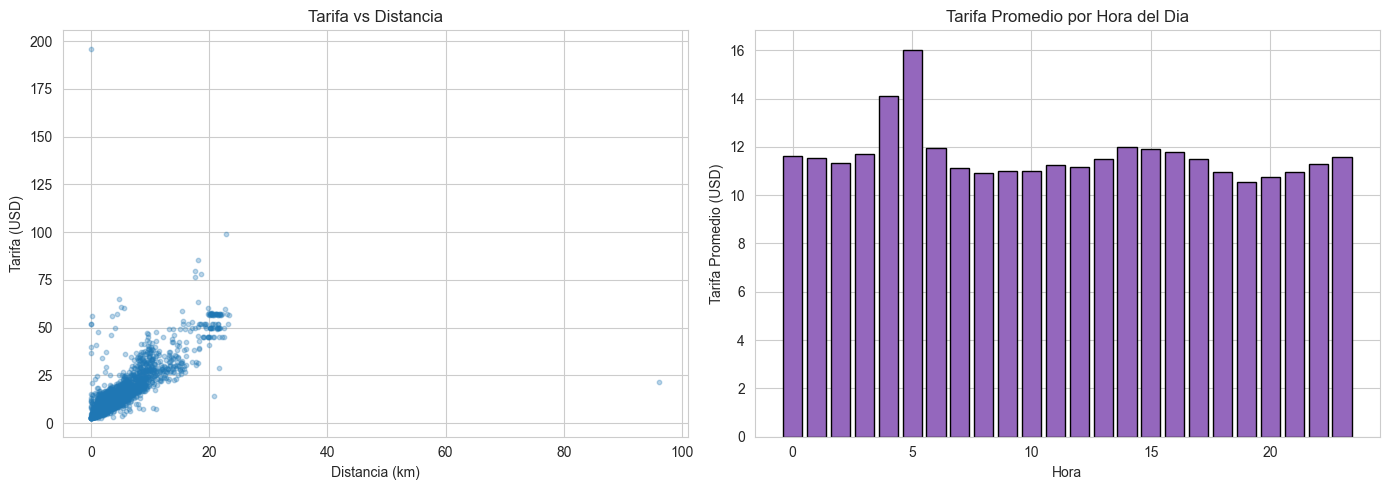

In [10]:
# Visualizar la relacion distancia vs tarifa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sample = df.sample(min(5000, len(df)), random_state=42)
axes[0].scatter(sample["distancia_km"], sample["fare_amount"], alpha=0.3, s=10)
axes[0].set_title("Tarifa vs Distancia")
axes[0].set_xlabel("Distancia (km)")
axes[0].set_ylabel("Tarifa (USD)")

# Tarifa promedio por hora
tarifa_por_hora = df.groupby("hora")["fare_amount"].mean()
axes[1].bar(tarifa_por_hora.index, tarifa_por_hora.values, color="#9467bd", edgecolor="k")
axes[1].set_title("Tarifa Promedio por Hora del Dia")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Tarifa Promedio (USD)")

plt.tight_layout()
plt.show()

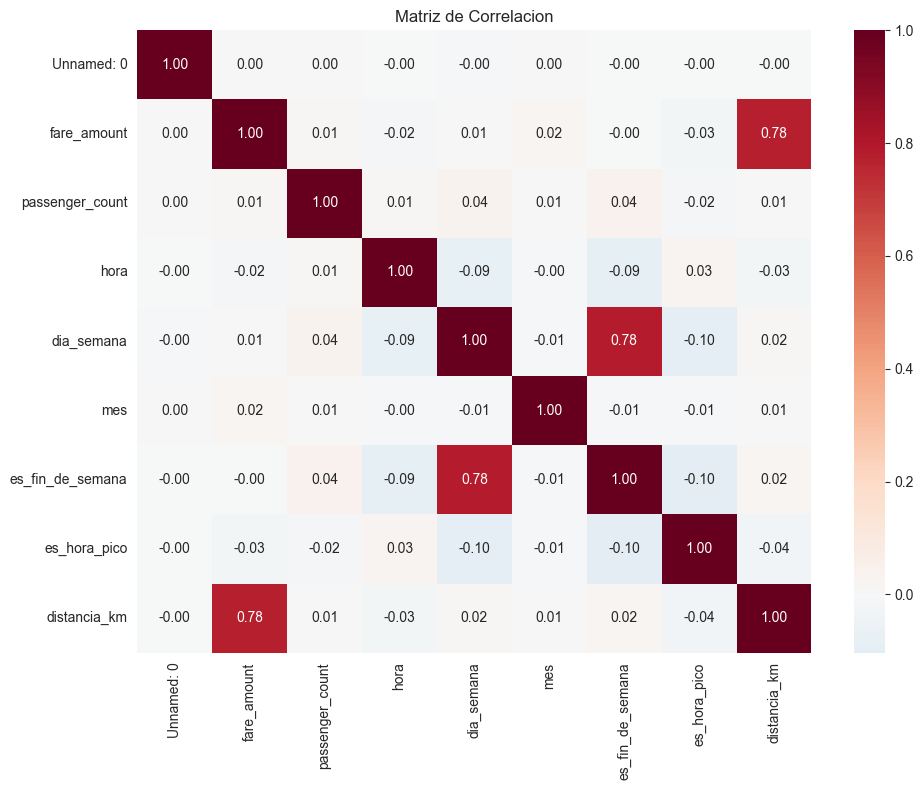


Correlacion con fare_amount:
distancia_km        0.778667
mes                 0.024120
passenger_count     0.011884
dia_semana          0.006257
Unnamed: 0          0.000694
es_fin_de_semana   -0.000165
hora               -0.020724
es_hora_pico       -0.025198


In [11]:
# Matriz de correlacion
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Matriz de Correlacion")
plt.tight_layout()
plt.show()

# Correlacion con la variable objetivo
print("\nCorrelacion con fare_amount:")
print(correlation_matrix["fare_amount"].drop("fare_amount").sort_values(ascending=False).to_string())

## 4. Entrenamiento con MLflow

Ahora entrenamos el modelo y registramos todo en MLflow a traves de DagsHub.

**Asegurate de tener tu archivo `.env` configurado con las credenciales de DagsHub.**

In [13]:
# Configurar MLflow con DagsHub
from src.config import setup_mlflow
setup_mlflow()

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=3647025e-8f8f-441a-be1f-917da40831e6&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=b28c191d788ee195f08a8feed0ffdd309a22c31060a7608fdcff31696c669cfc




Accessing as abdala9512

Repository march-18-dsrp-workshop doesn't exist, creating it under current user.

Initialized MLflow to track repo "abdala9512/march-18-dsrp-workshop"

Repository abdala9512/march-18-dsrp-workshop initialized!

2026/03/18 18:49:14 INFO mlflow.tracking.fluent: Experiment with name 'uber-fare-prediction' does not exist. Creating a new experiment.


MLflow configurado: https://dagshub.com/abdala9512/march-18-dsrp-workshop.mlflow
Experimento: uber-fare-prediction


In [14]:
# Preparar datos para entrenamiento
from src.data import prepare_data

X_train, X_test, y_train, y_test = prepare_data(df)

Train: 154576 muestras | Test: 38645 muestras


### 4.1 Entrenar Random Forest

In [15]:
from src.train import train_model
from src.evaluate import evaluate_model, log_metrics_to_mlflow, create_evaluation_plots

# Entrenar Random Forest
with mlflow.start_run(run_name="notebook-random-forest"):
    modelo_rf = train_model(X_train, y_train, model_type="random_forest")
    metricas_rf = evaluate_model(modelo_rf, X_test, y_test)
    log_metrics_to_mlflow(metricas_rf)
    
    y_pred_rf = modelo_rf.predict(X_test)
    create_evaluation_plots(y_test, y_pred_rf)
    
    mlflow.sklearn.log_model(modelo_rf, "model")
    rf_run_id = mlflow.active_run().info.run_id

print(f"\nRun ID: {rf_run_id}")
print(f"RMSE: {metricas_rf['rmse']:.4f}")
print(f"MAE:  {metricas_rf['mae']:.4f}")
print(f"R2:   {metricas_rf['r2']:.4f}")

Entrenando random_forest con parametros: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'random_state': 42}
Entrenamiento completado.
Metricas: RMSE=4.5989 | MAE=2.2513 | R2=0.7662
Metricas registradas en MLflow.


2026/03/18 18:49:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Graficos guardados en ./evaluation_plots.png


2026/03/18 18:49:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/18 18:50:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run notebook-random-forest at: https://dagshub.com/abdala9512/march-18-dsrp-workshop.mlflow/#/experiments/0/runs/b78488b5bc1a4b9798d196beb9bd9148
🧪 View experiment at: https://dagshub.com/abdala9512/march-18-dsrp-workshop.mlflow/#/experiments/0

Run ID: b78488b5bc1a4b9798d196beb9bd9148
RMSE: 4.5989
MAE:  2.2513
R2:   0.7662


### 4.2 Entrenar Gradient Boosting

In [16]:
# Entrenar Gradient Boosting para comparar
with mlflow.start_run(run_name="notebook-gradient-boosting"):
    modelo_gb = train_model(X_train, y_train, model_type="gradient_boosting")
    metricas_gb = evaluate_model(modelo_gb, X_test, y_test)
    log_metrics_to_mlflow(metricas_gb)
    
    y_pred_gb = modelo_gb.predict(X_test)
    create_evaluation_plots(y_test, y_pred_gb)
    
    mlflow.sklearn.log_model(modelo_gb, "model")
    gb_run_id = mlflow.active_run().info.run_id

print(f"\nRun ID: {gb_run_id}")
print(f"RMSE: {metricas_gb['rmse']:.4f}")
print(f"MAE:  {metricas_gb['mae']:.4f}")
print(f"R2:   {metricas_gb['r2']:.4f}")

Entrenando gradient_boosting con parametros: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'random_state': 42}
Entrenamiento completado.
Metricas: RMSE=4.5121 | MAE=2.2288 | R2=0.7750
Metricas registradas en MLflow.


2026/03/18 18:51:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Graficos guardados en ./evaluation_plots.png


2026/03/18 18:52:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/18 18:52:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run notebook-gradient-boosting at: https://dagshub.com/abdala9512/march-18-dsrp-workshop.mlflow/#/experiments/0/runs/2844db81a83c4bf18020f0647f6b4670
🧪 View experiment at: https://dagshub.com/abdala9512/march-18-dsrp-workshop.mlflow/#/experiments/0

Run ID: 2844db81a83c4bf18020f0647f6b4670
RMSE: 4.5121
MAE:  2.2288
R2:   0.7750


### 4.3 Comparacion de modelos

In [17]:
# Comparar ambos modelos lado a lado
comparacion = pd.DataFrame({
    "Random Forest": metricas_rf,
    "Gradient Boosting": metricas_gb,
}).T

print("Comparacion de modelos:")
print("=" * 50)
print(comparacion.round(4).to_string())

# Determinar el mejor modelo
mejor = "Random Forest" if metricas_rf["rmse"] < metricas_gb["rmse"] else "Gradient Boosting"
print(f"\nMejor modelo: {mejor}")

Comparacion de modelos:
                     rmse     mae      r2
Random Forest      4.5989  2.2513  0.7662
Gradient Boosting  4.5121  2.2288  0.7750

Mejor modelo: Gradient Boosting


In [18]:
# Visualizar comparacion de predicciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
sample_idx = np.random.choice(len(y_test), min(500, len(y_test)), replace=False)
y_test_sample = y_test.iloc[sample_idx]

axes[0].scatter(y_test_sample, y_pred_rf[sample_idx], alpha=0.4, s=15)
axes[0].plot([y_test_sample.min(), y_test_sample.max()], 
             [y_test_sample.min(), y_test_sample.max()], "r--", lw=2)
axes[0].set_title(f"Random Forest (RMSE={metricas_rf['rmse']:.2f})")
axes[0].set_xlabel("Tarifa Real (USD)")
axes[0].set_ylabel("Tarifa Predicha (USD)")

# Gradient Boosting
axes[1].scatter(y_test_sample, y_pred_gb[sample_idx], alpha=0.4, s=15, color="orange")
axes[1].plot([y_test_sample.min(), y_test_sample.max()], 
             [y_test_sample.min(), y_test_sample.max()], "r--", lw=2)
axes[1].set_title(f"Gradient Boosting (RMSE={metricas_gb['rmse']:.2f})")
axes[1].set_xlabel("Tarifa Real (USD)")
axes[1].set_ylabel("Tarifa Predicha (USD)")

plt.tight_layout()
plt.show()

/var/folders/65/xyj4xjq9355355kxr06pqfy80000gn/T/ipykernel_11942/2396789948.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 5. Champion / Challenger

Usamos la logica de Champion/Challenger para registrar el mejor modelo en el Model Registry de MLflow.

In [19]:
from src.champion_challenger import get_champion_metrics, compare_models, promote_to_champion, generate_report

# Usar las metricas del mejor modelo como Challenger
if metricas_rf["rmse"] < metricas_gb["rmse"]:
    challenger_metrics = metricas_rf
    challenger_run_id = rf_run_id
    print("Challenger: Random Forest")
else:
    challenger_metrics = metricas_gb
    challenger_run_id = gb_run_id
    print("Challenger: Gradient Boosting")

# Obtener metricas del Champion actual (si existe)
champion_metrics = get_champion_metrics()

# Comparar
comparison = compare_models(challenger_metrics, champion_metrics)
print(f"\nResultado: {comparison['reason']}")

Challenger: Gradient Boosting
No se encontro un modelo Champion registrado.

Resultado: No existe un Champion previo. El Challenger sera el primer Champion.


In [20]:
# Generar reporte
report = generate_report(comparison, challenger_metrics, champion_metrics)
print(report)

# Reporte de Entrenamiento: Champion vs Challenger

## Resultado: ✅ Challenger es MEJOR

**No existe un Champion previo. El Challenger sera el primer Champion.**

## Metricas

| Metrica | Champion | Challenger | Diferencia |
|---------|----------|------------|------------|
| RMSE | N/A | 4.5121 | Primer modelo |
| MAE | N/A | 2.2288 | Primer modelo |
| R2 | N/A | 0.7750 | Primer modelo |

## Graficos

![Evaluacion](evaluation_plots.png)

---
*Reporte generado automaticamente por el pipeline de MLOps*


In [21]:
# Promover a Champion si es mejor
# DESCOMENTA la siguiente linea para promover el modelo
# promote_to_champion(challenger_run_id)

## 6. Importancia de features

In [22]:
# Importancia de features del mejor modelo
mejor_modelo = modelo_rf if metricas_rf["rmse"] < metricas_gb["rmse"] else modelo_gb
feature_names = X_train.columns
importances = mejor_modelo.feature_importances_

# Ordenar por importancia
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(indices)), importances[indices], color="#2ca02c", edgecolor="k")
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices])
ax.invert_yaxis()
ax.set_title("Importancia de Features")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

print("\nRanking de features:")
for i, idx in enumerate(indices, 1):
    print(f"  {i}. {feature_names[idx]}: {importances[idx]:.4f}")


Ranking de features:
  1. distancia_km: 0.9666
  2. hora: 0.0136
  3. Unnamed: 0: 0.0127
  4. dia_semana: 0.0033
  5. mes: 0.0020
  6. es_fin_de_semana: 0.0010
  7. passenger_count: 0.0005
  8. es_hora_pico: 0.0003


/var/folders/65/xyj4xjq9355355kxr06pqfy80000gn/T/ipykernel_11942/4171199918.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Conclusiones

- La **distancia** es la feature mas importante para predecir la tarifa (como era de esperarse)
- Las features temporales (hora, dia de la semana) aportan informacion adicional
- La hora pico y el fin de semana capturan patrones de demanda
- El numero de pasajeros tiene poca influencia en la tarifa

### Siguientes pasos

1. Experimentar con diferentes hiperparametros
2. Crear una rama, modificar parametros en `src/train.py` y abrir un PR
3. El GitHub Action entrenara automaticamente y publicara un reporte CML
4. Usar `/train` en Claude Code para entrenar interactivamente